# **EDA**

#### Data Extraction


In [37]:
import pandas as pd 
from snowflake.connector import connect 
import warnings
warnings.filterwarnings('ignore')

details = {
    'user': 'NASRULKHAIR',
    'password': 'C@de0123456789',
    'account': 'SSDSCZP-MD39179',
    'warehouse': 'BANK_WH',
    'database': 'BANK_ANALYTICS_DB',
    'schema': 'CLEAN'
}

conn = connect(**details)

query = 'SELECT * FROM BANK_CHURN_CLEANED'
df_clean = pd.read_sql(query, conn)
df_clean.head()

,customer_id,credit_score,geography_id,country_name,gender_id,gender,age,tenure,balance,num_of_products,cr_card_id,credit_card_holder,active_id,active_member,estimated_salary,exit_id,churned,bank_doj
0,15634602,619,1,France,2,Female,42,7,0.00,1,1,Credit Card Holder,1,Active Member,101348.88,1,Exit,1458691200000000000
1,15647311,608,2,Spain,2,Female,41,4,83807.86,1,0,Non Credit Card Holder,1,Active Member,112542.58,0,Retain,1539043200000000000
2,15619304,502,1,France,2,Female,42,4,159660.80,3,1,Credit Card Holder,0,Non Active Member,113931.57,1,Exit,1553472000000000000
3,15701354,699,1,France,2,Female,39,3,0.00,2,0,Non Credit Card Holder,0,Non Active Member,93826.63,0,Retain,1571875200000000000
4,15737888,850,2,Spain,2,Female,43,3,125510.82,1,1,Credit Card Holder,1,Active Member,79084.10,0,Retain,1574380800000000000


In [38]:
# converting bank_doj to datetime format
df_clean['bank_doj'] = pd.to_datetime(df_clean['bank_doj'])
df_clean['bank_doj'].head()

0   2016-03-23
1   2018-10-09
2   2019-03-25
3   2019-10-24
4   2019-11-22
Name: bank_doj, dtype: datetime64[ns]

In [39]:
df_clean.head()


,customer_id,credit_score,geography_id,country_name,gender_id,gender,age,tenure,balance,num_of_products,cr_card_id,credit_card_holder,active_id,active_member,estimated_salary,exit_id,churned,bank_doj
0,15634602,619,1,France,2,Female,42,7,0.00,1,1,Credit Card Holder,1,Active Member,101348.88,1,Exit,2016-03-23
1,15647311,608,2,Spain,2,Female,41,4,83807.86,1,0,Non Credit Card Holder,1,Active Member,112542.58,0,Retain,2018-10-09
2,15619304,502,1,France,2,Female,42,4,159660.80,3,1,Credit Card Holder,0,Non Active Member,113931.57,1,Exit,2019-03-25
3,15701354,699,1,France,2,Female,39,3,0.00,2,0,Non Credit Card Holder,0,Non Active Member,93826.63,0,Retain,2019-10-24
4,15737888,850,2,Spain,2,Female,43,3,125510.82,1,1,Credit Card Holder,1,Active Member,79084.10,0,Retain,2019-11-22


##### Initial Data Inspection


In [40]:
print(df_clean.info())
print(df_clean.describe)
print(df_clean['churned'].value_counts(normalize=True) * 100)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         10000 non-null  int64         
 1   credit_score        10000 non-null  int64         
 2   geography_id        10000 non-null  int64         
 3   country_name        10000 non-null  object        
 4   gender_id           10000 non-null  int64         
 5   gender              10000 non-null  object        
 6   age                 10000 non-null  int64         
 7   tenure              10000 non-null  int64         
 8   balance             10000 non-null  float64       
 9   num_of_products     10000 non-null  int64         
 10  cr_card_id          10000 non-null  int64         
 11  credit_card_holder  10000 non-null  object        
 12  active_id           10000 non-null  int64         
 13  active_member       10000 non-null  object     

#### Univariate Analysis

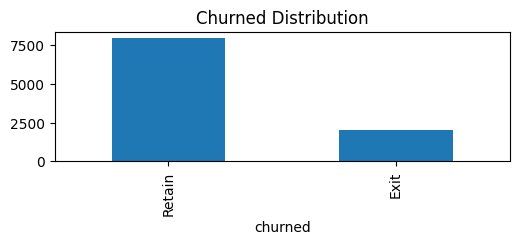

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
'''
# Age distribution
plt.subplot(2,2,1)
df_clean['age'].hist(bins=20)
plt.title('Age Distribution')

# Credit Score distribution
plt.subplot(2,2,2)
df_clean['credit_score'].hist(bins=20)
plt.title('Credit Score Distribution')

'''
# Churned distribution
plt.subplot(2,2,3)
df_clean['churned'].value_counts().plot(kind='bar')
plt.title('Churned Distribution')



plt.tight_layout()
plt.show()

**Insights**
1. Majority of customers are aged 35-40
2. Credit scores cluster around 600–700 range
3. Credit scores cluster around 600–700 range




#### Bivariate Analysis


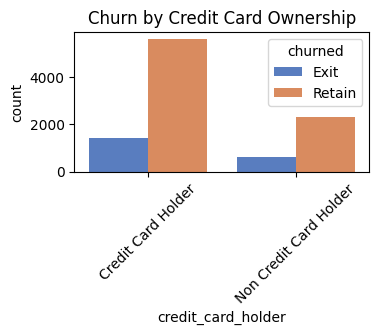

In [49]:
# Churn by Geography

plt.figure(figsize=(7,5))


'''
plt.subplot(2,2,1)
sns.countplot(data=df_clean, x='country_name', hue='churned', palette='Set2')
plt.title('Churn by Country')
plt.xlabel('Country')
plt.ylabel('Count')

# Churn By Gender
plt.subplot(2,2,2)
sns.countplot(data=df_clean, x='gender', hue='churned', palette='pastel')
plt.title('Churn by Gender')
plt.show()


# Churn by Active Member Status
plt.subplot(2,2,3)
sns.countplot(data=df_clean, x='active_member', hue='churned', palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Churn by Active vs Non Active Member')


'''
# Chrun by Credit Crad Holder Status
plt.subplot(2,2,4)
sns.countplot(data=df_clean, x='credit_card_holder', hue='churned', palette='muted')
plt.xticks(rotation=45)
plt.title('Churn by Credit Card Ownership')

plt.tight_layout()
plt.show()

**Insights**
1. Older Customer churn more ofen
2. credit score not bringing impact towards churn rate


##### Correlation Analysis
 

              customer_id  credit_score  geography_id  gender_id       age  \
customer_id      1.000000      0.005308      0.000821   0.002641  0.009497   
credit_score     0.005308      1.000000      0.008267   0.002857 -0.003965   
geography_id     0.000821      0.008267      1.000000   0.016936  0.048092   
gender_id        0.002641      0.002857      0.016936   1.000000  0.027544   
age              0.009497     -0.003965      0.048092   0.027544  1.000000   

                tenure   balance  num_of_products  cr_card_id  active_id  \
customer_id   0.003884 -0.012419         0.016972   -0.014025   0.001665   
credit_score -0.007355  0.006268         0.012238   -0.005458   0.025651   
geography_id -0.003858  0.348700        -0.006180    0.004036  -0.012692   
gender_id    -0.008018 -0.012087         0.021859   -0.005766  -0.022544   
age           0.010788  0.028308        -0.030680   -0.011721   0.085472   

              estimated_salary   exit_id  
customer_id           0.015271 

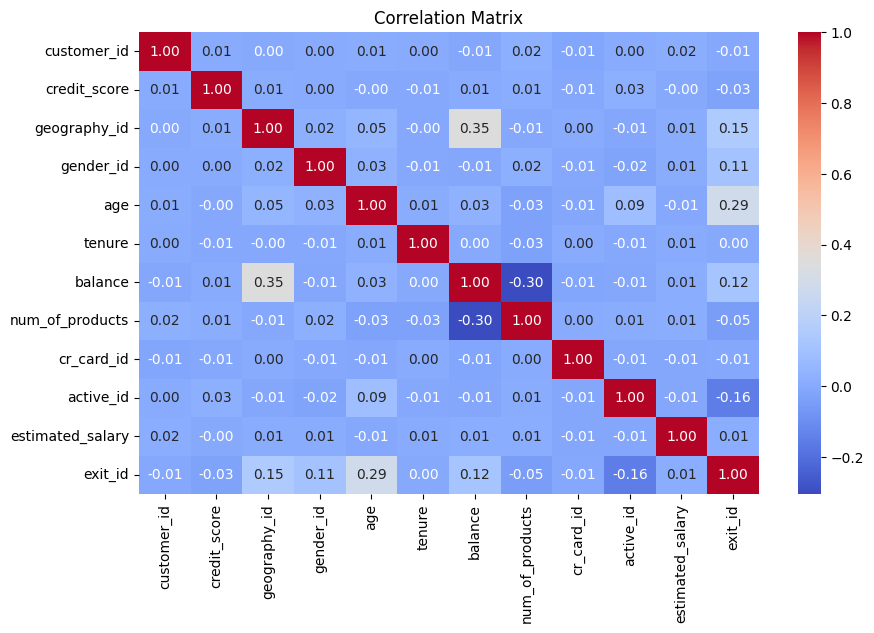

exit_id             1.000000
age                 0.285323
geography_id        0.153771
balance             0.118533
gender_id           0.106512
estimated_salary    0.012097
tenure              0.000699
customer_id        -0.006248
cr_card_id         -0.007138
credit_score       -0.027094
num_of_products    -0.047820
active_id          -0.156128
Name: exit_id, dtype: float64

In [43]:
# Convert churn to numeric (if not already)
#df_clean['churn_flag'] = df_clean['exit_id'].astype(int)

# Select only numeric columns
corr = df_clean.corr(numeric_only=True)
print(corr.head())

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Focused correlation with churn
corr['exit_id'].sort_values(ascending=False)

#### Segmentation Analysis


  country_name  Total_Customers  Churned_Customers  Churn_Rate_%
1      Germany             2509                814         32.44
2        Spain             2477                413         16.67
0       France             5014                810         16.15


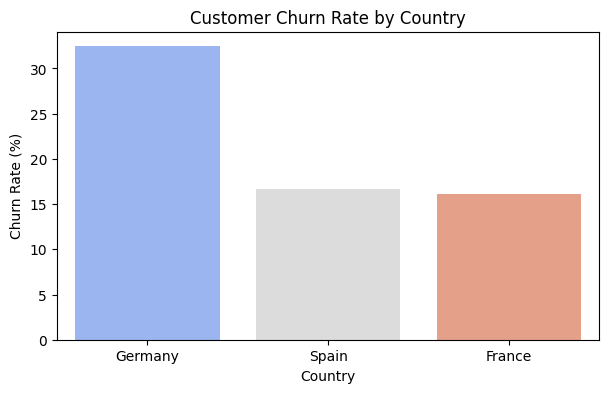

In [54]:

churn_by_country = df_clean.groupby("country_name", as_index=False).agg(
    Total_Customers=("churned", "count"),
    Churned_Customers=('exit_id', 'sum')
)

churn_by_country['churn_rate%'] = round(
    (churn_by_country['Churned_Customers'] * 100.0) / churn_by_country['Total_Customers'], 2
)
churn_by_country = churn_by_country.sort_values(by="churn_rate%", ascending=False)
churn_by_country# ✅ Churn Segmentation by Country
churn_by_country = (
    df_clean
    .groupby("country_name", as_index=False)
    .agg(
        Total_Customers=("customer_id", "count"),     # total count of customers
        Churned_Customers=("exit_id", "sum")          # count of churned (exit_id = 1)
    )
)

# Calculate churn rate (%)
churn_by_country["Churn_Rate_%"] = (
    churn_by_country["Churned_Customers"] / churn_by_country["Total_Customers"] * 100
).round(2)

# Sort countries by highest churn rate
churn_by_country = churn_by_country.sort_values(by="Churn_Rate_%", ascending=False)

# Display result
print(churn_by_country)

plt.figure(figsize=(7,4))
sns.barplot(data=churn_by_country, x="country_name", y="Churn_Rate_%", palette="coolwarm")
plt.title("Customer Churn Rate by Country")
plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")
plt.show()


**Insights**
1. Country influences churn significantly